<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/loveall/cervical-cancer-risk-classification">Risque de cancer du col de l'utérus</a></div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer_logo.png" width="96"></th>
 </tr>
</table>

<div style='text-align: center'>
<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/CervicalCancer.jpg" width="1024">
</div>


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>
## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries </div></b>

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

Si vous devez utiliser la librairie « imblearn » il est obligatoire d’utiliser la variable d’environnement suivante : SCIPY_ARRAY_API = 1

In [2]:
from sklearn.model_selection import train_test_split

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))
from prjFormation import palette

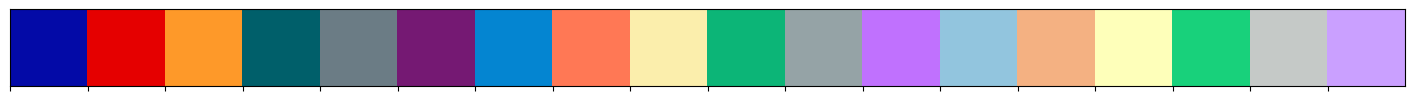

In [4]:
# palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
#             "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
#             "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
#           ]
sns.palplot(sns.color_palette(palette[:18]))

In [5]:
from classificationBinaires import initDictionnaireClassificateurs, executionEssaiComparaisonClassificateurs,\
                                   affichageEvolutionMetriques, affichageROC, executeValidationCroisee, afficheSeparationsBinaires

In [6]:
from prjFormation import initProjet,affichageDonnees2d,affichageDonnees3d,createLinkageMatrix, afficheDendrogram,\
                         affichageDistribution,afficheColonneCible, add_median_labels, formatPct

In [7]:
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

In [8]:
projet = initProjet(repertoireRacine='.',nomProjet='CervicalCancerRisk')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

In [9]:
donnees = pd.read_csv('../donnees/Cervical Cancer Risk/kag_risk_factors_cervical_cancer.csv',
                      na_values='?')
donnees.columns = list(map(lambda x: str(x).replace(':',' '),donnees.columns))
cible = 'Dx Cancer'
donnees.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs Time since first diagnosis,STDs Time since last diagnosis,Dx Cancer,Dx CIN,Dx HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [10]:
donnees.sample(5)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs Time since first diagnosis,STDs Time since last diagnosis,Dx Cancer,Dx CIN,Dx HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
101,30,5.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,...,11.0,11.0,0,0,0,0,0,0,1,0
578,19,1.0,18.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,1,0,1,1,1,1,1,1
656,23,1.0,19.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
229,27,3.0,15.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,...,NaN,NaN,0,1,0,1,0,0,0,0
608,19,2.0,16.0,1.0,0.0,0.0,0.0,1.0,2.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [11]:
donnees.shape

(858, 36)

In [12]:
donnees.isna().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs condylomatosis                   105
STDs cervical condylomatosis          105
STDs vaginal condylomatosis           105
STDs vulvo-perineal condylomatosis    105
STDs syphilis                         105
STDs pelvic inflammatory disease      105
STDs genital herpes                   105
STDs molluscum contagiosum            105
STDs AIDS                             105
STDs HIV                              105
STDs Hepatitis B                  

In [13]:
donnees[donnees['Hormonal Contraceptives'].isna()].shape, donnees[donnees['Hormonal Contraceptives'].isna()]['Hormonal Contraceptives (years)'].isna().sum()

((108, 36), 108)

In [14]:
for col in donnees.columns:
    print(col,'\n\t',donnees[col].sort_values().unique())

Age 
	 [13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 59 70 79 84]
Number of sexual partners 
	 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 15. 28. nan]
First sexual intercourse 
	 [10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27.
 28. 29. 32. nan]
Num of pregnancies 
	 [ 0.  1.  2.  3.  4.  5.  6.  7.  8. 10. 11. nan]
Smokes 
	 [ 0.  1. nan]
Smokes (years) 
	 [ 0.          0.16        0.5         1.          1.26697291  2.
  3.          4.          5.          6.          7.          8.
  9.         10.         11.         12.         13.         14.
 15.         16.         18.         19.         20.         21.
 22.         24.         28.         32.         34.         37.
         nan]
Smokes (packs/year) 
	 [0.00000000e+00 1.00000000e-03 3.00000000e-03 2.50000000e-02
 4.00000000e-02 5.00000000e-02 1.00000000e-01 1.50000000e-01
 1.60000000e-01 2.00000000e-01 2.50000000e-01 3.00000000e-

In [15]:
donnees.fillna(0,inplace=True)

In [16]:
variableQualitatives = list(donnees.drop(columns=['Smokes (years)','Smokes (packs/year)','Hormonal Contraceptives (years)','IUD (years)', cible]).columns)

In [17]:
donnees[variableQualitatives+[cible]] = donnees[variableQualitatives+[cible]].astype('int16')

In [18]:
variableQualitatives

['Age',
 'Number of sexual partners',
 'First sexual intercourse',
 'Num of pregnancies',
 'Smokes',
 'Hormonal Contraceptives',
 'IUD',
 'STDs',
 'STDs (number)',
 'STDs condylomatosis',
 'STDs cervical condylomatosis',
 'STDs vaginal condylomatosis',
 'STDs vulvo-perineal condylomatosis',
 'STDs syphilis',
 'STDs pelvic inflammatory disease',
 'STDs genital herpes',
 'STDs molluscum contagiosum',
 'STDs AIDS',
 'STDs HIV',
 'STDs Hepatitis B',
 'STDs HPV',
 'STDs  Number of diagnosis',
 'STDs  Time since first diagnosis',
 'STDs  Time since last diagnosis',
 'Dx CIN',
 'Dx HPV',
 'Dx',
 'Hinselmann',
 'Schiller',
 'Citology',
 'Biopsy']

In [19]:
donnees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int16  
 1   Number of sexual partners           858 non-null    int16  
 2   First sexual intercourse            858 non-null    int16  
 3   Num of pregnancies                  858 non-null    int16  
 4   Smokes                              858 non-null    int16  
 5   Smokes (years)                      858 non-null    float64
 6   Smokes (packs/year)                 858 non-null    float64
 7   Hormonal Contraceptives             858 non-null    int16  
 8   Hormonal Contraceptives (years)     858 non-null    float64
 9   IUD                                 858 non-null    int16  
 10  IUD (years)                         858 non-null    float64
 11  STDs                                858 non-n

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonApprentissageTest.png" width="800">

In [20]:
X = donnees.drop(columns=cible).copy()
y = donnees[cible]
y.index = X.index

In [21]:
X_train, X_test, y_train, y_test = train_test_split( X, 
                                                     y, 
                                                     test_size=0.3, #train_size
                                                     random_state=0, 
                                                     stratify = y
                                                   ) 

In [22]:
donnees.loc[X_train.index,'échantillon'] = 'apprentissage'
donnees.loc[X_test.index ,'échantillon'] = 'test'
donnees.reset_index(inplace=True)
donnees.set_index(['échantillon',cible],inplace=True)

donnees.to_parquet(os.path.join(projet.repertoireDonnees,'donnees_echantillons.parquet'))

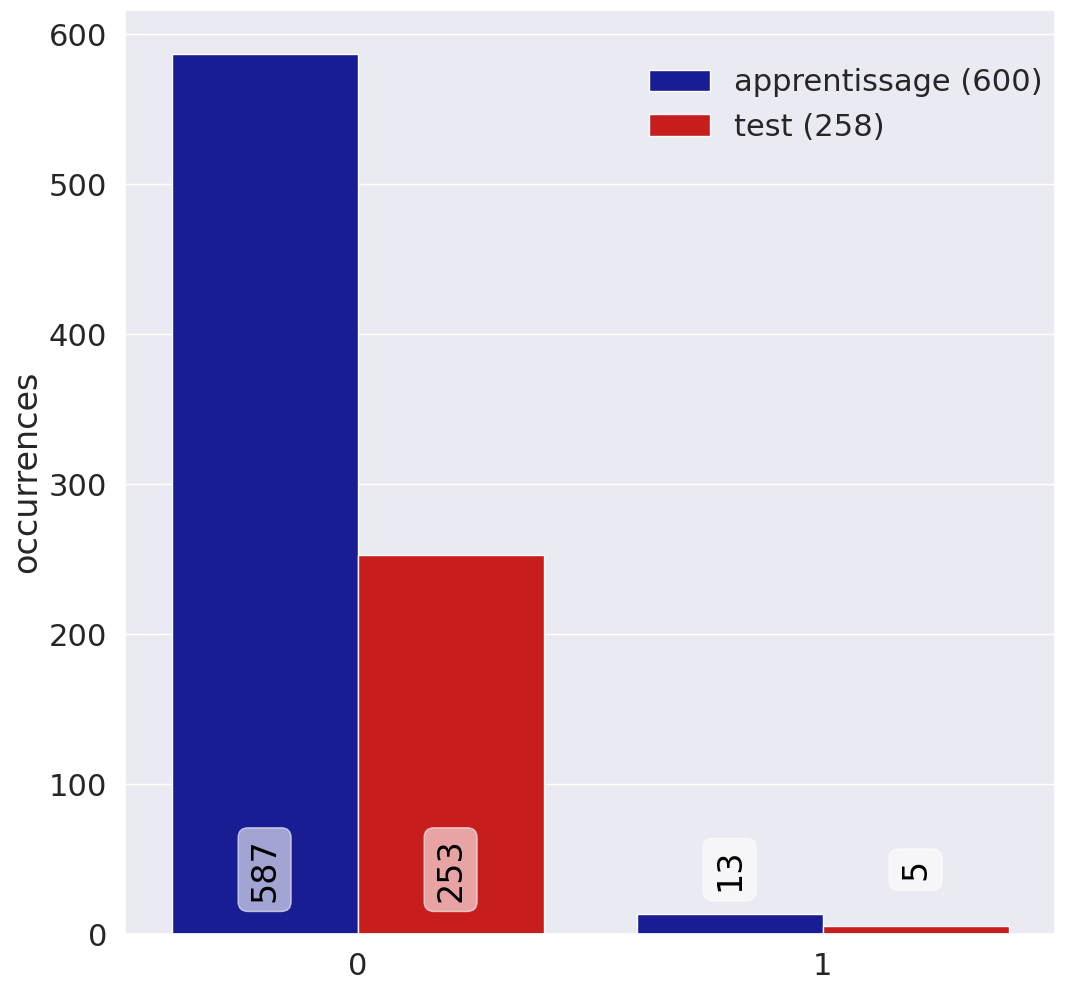

In [23]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(12,12))
afficheSeparationsBinaires(donnees, palette, ax, cible=cible)

In [24]:
X = donnees.copy()
y = donnees.reset_index()[cible]
y.index = X.index

In [25]:
X_train, X_test, y_train, y_test = X.loc[('apprentissage'),:],\
                                   X.loc[('test'),:],\
                                   y.loc[('apprentissage')],\
                                   y.loc[('test')] 

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Déclaration des classificateurs </div></b>

In [26]:
classificateursDict =  initDictionnaireClassificateurs(arbres=12)
classificateursDict.pop('LightGBM'),\
classificateursDict.pop('XGBoost'),\
classificateursDict.pop('Radial_NuSVM'),\
classificateursDict.pop('Poly_NuSVM'),\
classificateursDict.pop('QuadraticDiscriminant')

(LGBMClassifier(min_child_samples=10, min_split_gain=0.01, n_estimators=12,
                num_leaves=20, reg_alpha=0.1, reg_lambda=20),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=12,
               n_jobs=None, num_parallel_tree=None, ...),
 NuSVC(gamma=0.5, nu=0.195, probability=True),
 NuSVC(kernel='poly', nu=0.1, probability=True

In [27]:
classificateursDict

{'Random_Forest': RandomForestClassifier(max_depth=6, max_features=3, min_samples_split=4,
                        n_estimators=12, n_jobs=-1),
 'AdaBoost': AdaBoostClassifier(n_estimators=12),
 'LogisticRegression': LogisticRegression(C=0.81113, max_iter=3000, n_jobs=-1),
 'Stochastic_GD': SGDClassifier(alpha=0.01, loss='log_loss', max_iter=200),
 'Gaussian_Process': GaussianProcessClassifier(n_jobs=-1),
 'Nearest_Neighbors': KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1, n_neighbors=17, p=1,
                      weights='distance'),
 'Linear_SVM': SVC(C=10, kernel='linear', probability=True),
 'GaussianNaiveBayes': GaussianNB(),
 'Neural_Net': MLPClassifier(alpha=1)}